<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 13: Temporal Convolutional Networks (TCN) with Dilated Causal
Convolutions
● Objective: Model complex, non-linear multi-dimensional time-series sequences by
constructing receptive field architectures with zero temporal look-ahead leaks.
● Required Tech Stack: PyTorch, Pandas, NumPy, Matplotlib.
● Task Description: Students must build a Temporal Convolutional Network. They must
write customized 1D convolutional layers featuring dilated causal convolutions,
systematically doubling dilation factors ( ) to capture long-range
historical structures, and evaluate predictive errors against classical sequential models.

In [1]:
#Step 1 — Install Required Libraries
!pip install torch pandas numpy matplotlib scikit-learn

In [2]:
#Step 2 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [3]:
#Step 3 — Select Device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Using device: cpu


In [4]:
 #Step 4 — Load Time-Series Dataset Automatically
url = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/"
    "airline-passengers.csv"
)

df = pd.read_csv(url)

print(df.head())
print("\nDataset shape:", df.shape)

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Dataset shape: (144, 2)


In [5]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None

Missing values:
Month         0
Passengers    0
dtype: int64


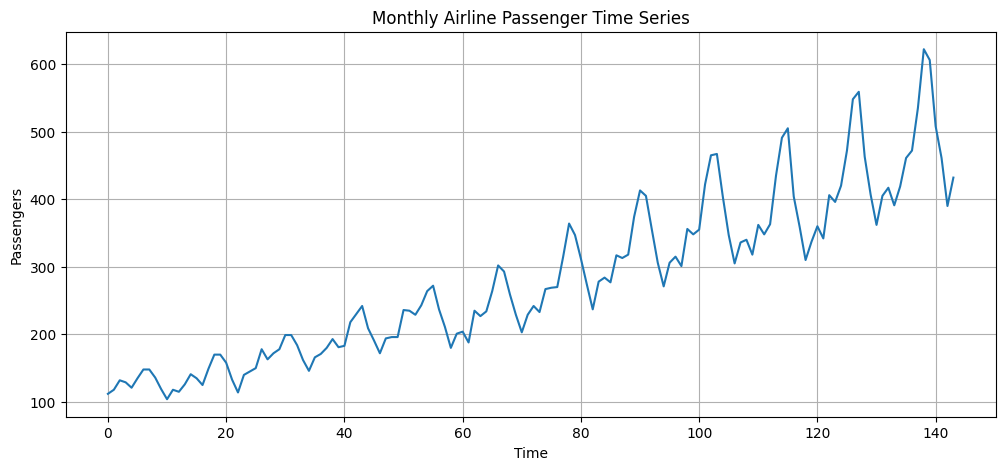

In [6]:
#Step 5 — Visualize Original Time Series
plt.figure(figsize=(12, 5))

plt.plot(
    df["Passengers"]
)

plt.xlabel("Time")

plt.ylabel("Passengers")

plt.title(
    "Monthly Airline Passenger Time Series"
)

plt.grid()

plt.show()

In [7]:
#Step 6 — Convert Date Column
df["Month"] = pd.to_datetime(
    df["Month"]
)

df = df.sort_values(
    "Month"
).reset_index(drop=True)

print(df.head())

       Month  Passengers
0 1949-01-01         112
1 1949-02-01         118
2 1949-03-01         132
3 1949-04-01         129
4 1949-05-01         121


In [8]:
#Step 7 — Normalize Data
scaler = MinMaxScaler()

values = df[
    ["Passengers"]
].values.astype(
    np.float32
)

scaled_values = scaler.fit_transform(
    values
)

print(
    "Original shape:",
    values.shape
)

print(
    "Scaled shape:",
    scaled_values.shape
)

Original shape: (144, 1)
Scaled shape: (144, 1)


In [12]:
#Step 8 — Create Time-Series Sequences
SEQUENCE_LENGTH = 12


In [13]:
def create_sequences(
    data,
    sequence_length
):

    X = []
    y = []

    for i in range(
        len(data) - sequence_length
    ):

        X.append(
            data[
                i:i + sequence_length
            ]
        )

        y.append(
            data[
                i + sequence_length
            ]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [14]:
X, y = create_sequences(
    scaled_values,
    SEQUENCE_LENGTH
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (132, 12, 1)
y shape: (132, 1)


In [15]:
#Step 9 — Train/Test Split
split = int(
    len(X) * 0.8
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 105
Testing samples: 27


In [16]:
#Step 10 — Convert to PyTorch Tensors
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).permute(0, 2, 1)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).permute(0, 2, 1)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

X_train: torch.Size([105, 1, 12])
y_train: torch.Size([105, 1])


In [17]:
#Step 11 — Create DataLoader
train_dataset = TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

print(
    "Number of batches:",
    len(train_loader)
)

Number of batches: 7


In [18]:
#Step 12 — Create Custom Causal Convolution
class CausalConv1d(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation
    ):

        super().__init__()

        self.padding = (
            (kernel_size - 1)
            * dilation
        )

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=self.padding,
            dilation=dilation
        )

    def forward(self, x):

        output = self.conv(x)

        # Remove values generated
        # from right-side padding
        if self.padding > 0:

            output = output[
                :,
                :,
                :-self.padding
            ]

        return output

In [19]:
#Step 13 — Test Causal Convolution
test_input = torch.randn(
    2,
    1,
    12
)

causal_layer = CausalConv1d(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    dilation=1
)

test_output = causal_layer(
    test_input
)

print(
    "Input shape:",
    test_input.shape
)

print(
    "Output shape:",
    test_output.shape
)

Input shape: torch.Size([2, 1, 12])
Output shape: torch.Size([2, 16, 12])


In [20]:
#Step 14 — Create TCN Residual Block
class TemporalBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):

        super().__init__()

        self.conv1 = CausalConv1d(
            in_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.relu1 = nn.ReLU()

        self.dropout1 = nn.Dropout(
            dropout
        )

        self.conv2 = CausalConv1d(
            out_channels,
            out_channels,
            kernel_size,
            dilation
        )

        self.relu2 = nn.ReLU()

        self.dropout2 = nn.Dropout(
            dropout
        )

        # Residual projection
        if in_channels != out_channels:

            self.downsample = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.downsample = None

        self.final_relu = nn.ReLU()

    def forward(self, x):

        output = self.conv1(x)
        output = self.relu1(output)
        output = self.dropout1(output)

        output = self.conv2(output)
        output = self.relu2(output)
        output = self.dropout2(output)

        if self.downsample is not None:

            residual = self.downsample(x)

        else:

            residual = x

        output = (
            output +
            residual
        )

        return self.final_relu(
            output
        )

In [21]:
#Step 15 — Build Complete TCN
class TCN(nn.Module):

    def __init__(
        self,
        input_channels=1,
        channels=[16, 32, 32, 32],
        kernel_size=3,
        dropout=0.2
    ):

        super().__init__()

        layers = []

        for i in range(
            len(channels)
        ):

            dilation = 2 ** i

            in_channels = (
                input_channels
                if i == 0
                else channels[i - 1]
            )

            out_channels = (
                channels[i]
            )

            layers.append(

                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation,
                    dropout
                )
            )

        self.network = nn.Sequential(
            *layers
        )

        self.fc = nn.Linear(
            channels[-1],
            1
        )

    def forward(self, x):

        x = self.network(x)

        # Use final temporal output
        x = x[:, :, -1]

        x = self.fc(x)

        return x

In [22]:
#Step 16 — Initialize TCN
model = TCN().to(device)

print(model)

TCN(
  (network): Sequential(
    (0): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(2,))
      )
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(1, 16, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      )
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (downsample): Conv1d(16, 32, kernel_size=(1,), stride=(1,

In [23]:
for i in range(4):

    print(
        f"Layer {i + 1}: "
        f"Dilation = {2 ** i}"
    )

Layer 1: Dilation = 1
Layer 2: Dilation = 2
Layer 3: Dilation = 4
Layer 4: Dilation = 8


In [24]:
#Step 17 — Calculate Receptive Field
kernel_size = 3

dilations = [
    1,
    2,
    4,
    8
]

receptive_field = (
    1 +
    (kernel_size - 1)
    * sum(dilations)
)

print(
    "Approximate receptive field:",
    receptive_field
)

Approximate receptive field: 31


In [25]:
actual_receptive_field = (
    1 +
    2
    * (kernel_size - 1)
    * sum(dilations)
)

print(
    "TCN receptive field:",
    actual_receptive_field
)

TCN receptive field: 61


In [26]:
#Step 18 — Define Loss and Optimizer
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 100

In [27]:
#Step 19 — Train TCN
training_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            device
        )

        y_batch = y_batch.to(
            device
        )

        predictions = model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
        )

    average_loss = (
        total_loss /
        len(train_loader)
    )

    training_losses.append(
        average_loss
    )

    if (
        (epoch + 1) % 10 == 0
        or epoch == 0
    ):

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {average_loss:.6f}"
        )

Epoch [1/100] Loss: 0.034109
Epoch [10/100] Loss: 0.004573
Epoch [20/100] Loss: 0.003651
Epoch [30/100] Loss: 0.004038
Epoch [40/100] Loss: 0.002841
Epoch [50/100] Loss: 0.002642
Epoch [60/100] Loss: 0.002922
Epoch [70/100] Loss: 0.002762
Epoch [80/100] Loss: 0.002505
Epoch [90/100] Loss: 0.002653
Epoch [100/100] Loss: 0.001543


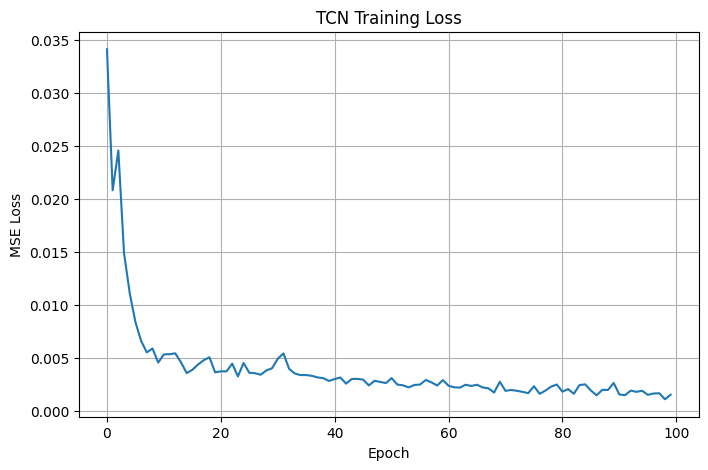

In [28]:
#Step 20 — Plot Training Loss
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    training_losses
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "TCN Training Loss"
)

plt.grid()

plt.show()

In [29]:
#Step 21 — Make Predictions
model.eval()

with torch.no_grad():

    predictions = model(
        X_test.to(device)
    )

predictions = (
    predictions
    .cpu()
    .numpy()
)

actual = (
    y_test
    .numpy()
)

print(
    "Prediction shape:",
    predictions.shape
)

Prediction shape: (27, 1)


In [30]:
#Step 22 — Convert Back to Original Scale
predictions_original = (
    scaler.inverse_transform(
        predictions
    )
)

actual_original = (
    scaler.inverse_transform(
        actual
    )
)

In [31]:
for i in range(
    min(10, len(actual_original))
):

    print(
        f"Actual: "
        f"{actual_original[i][0]:.0f} | "
        f"Predicted: "
        f"{predictions_original[i][0]:.0f}"
    )

Actual: 359 | Predicted: 351
Actual: 310 | Predicted: 332
Actual: 337 | Predicted: 320
Actual: 360 | Predicted: 334
Actual: 342 | Predicted: 353
Actual: 406 | Predicted: 338
Actual: 396 | Predicted: 385
Actual: 420 | Predicted: 395
Actual: 472 | Predicted: 447
Actual: 548 | Predicted: 494


In [32]:
#Step 23 — Calculate TCN Prediction Errors
tcn_mae = mean_absolute_error(
    actual_original,
    predictions_original
)

tcn_mse = mean_squared_error(
    actual_original,
    predictions_original
)

tcn_rmse = np.sqrt(
    tcn_mse
)

print(
    "TCN MAE:",
    tcn_mae
)

print(
    "TCN MSE:",
    tcn_mse
)

print(
    "TCN RMSE:",
    tcn_rmse
)

TCN MAE: 37.53809356689453
TCN MSE: 2063.174560546875
TCN RMSE: 45.42218137151578


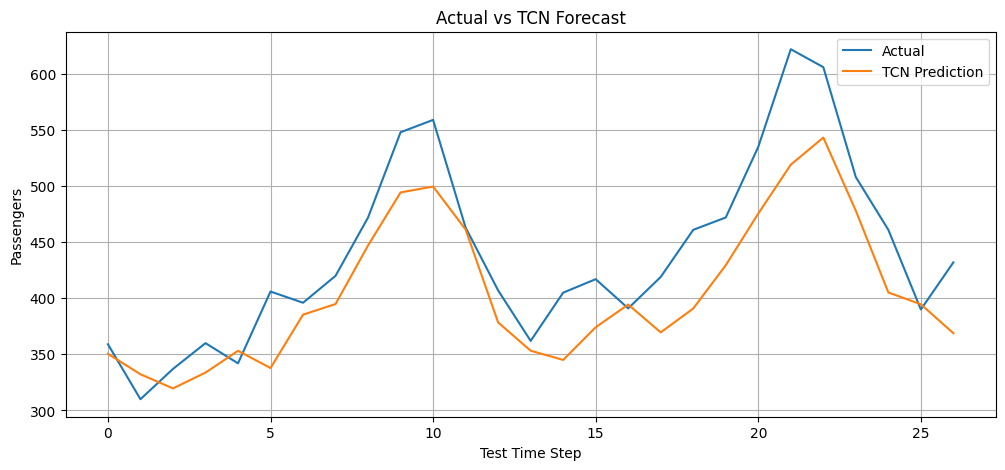

In [33]:
#Step 24 — Plot Actual vs TCN Prediction
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    actual_original,
    label="Actual"
)

plt.plot(
    predictions_original,
    label="TCN Prediction"
)

plt.xlabel(
    "Test Time Step"
)

plt.ylabel(
    "Passengers"
)

plt.title(
    "Actual vs TCN Forecast"
)

plt.legend()

plt.grid()

plt.show()

In [34]:
#Step 25 — Prepare Baseline Data
X_train_baseline = (
    X_train
    .squeeze(1)
    .numpy()
)

X_test_baseline = (
    X_test
    .squeeze(1)
    .numpy()
)

y_train_baseline = (
    y_train
    .numpy()
    .ravel()
)

print(
    X_train_baseline.shape
)

print(
    X_test_baseline.shape
)

(105, 12)
(27, 12)


In [35]:
#Step 26 — Train Classical Autoregressive Baseline
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_baseline,
    y_train_baseline
)

LinearRegression()

In [36]:
baseline_predictions = (
    baseline_model.predict(
        X_test_baseline
    )
)

baseline_predictions = (
    baseline_predictions
    .reshape(-1, 1)
)

In [37]:
baseline_original = (
    scaler.inverse_transform(
        baseline_predictions
    )
)

In [38]:
#Step 27 — Baseline Errors
baseline_mae = mean_absolute_error(
    actual_original,
    baseline_original
)

baseline_mse = mean_squared_error(
    actual_original,
    baseline_original
)

baseline_rmse = np.sqrt(
    baseline_mse
)

print(
    "Baseline MAE:",
    baseline_mae
)

print(
    "Baseline MSE:",
    baseline_mse
)

print(
    "Baseline RMSE:",
    baseline_rmse
)

Baseline MAE: 14.125669479370117
Baseline MSE: 332.2617492675781
Baseline RMSE: 18.22804842180254


In [39]:
#Step 28 — Compare TCN vs Classical Model
results = pd.DataFrame({

    "Model": [
        "TCN",
        "Autoregressive Linear Model"
    ],

    "MAE": [
        tcn_mae,
        baseline_mae
    ],

    "MSE": [
        tcn_mse,
        baseline_mse
    ],

    "RMSE": [
        tcn_rmse,
        baseline_rmse
    ]
})

print(results)

                         Model        MAE          MSE       RMSE
0                          TCN  37.538094  2063.174561  45.422181
1  Autoregressive Linear Model  14.125669   332.261749  18.228048


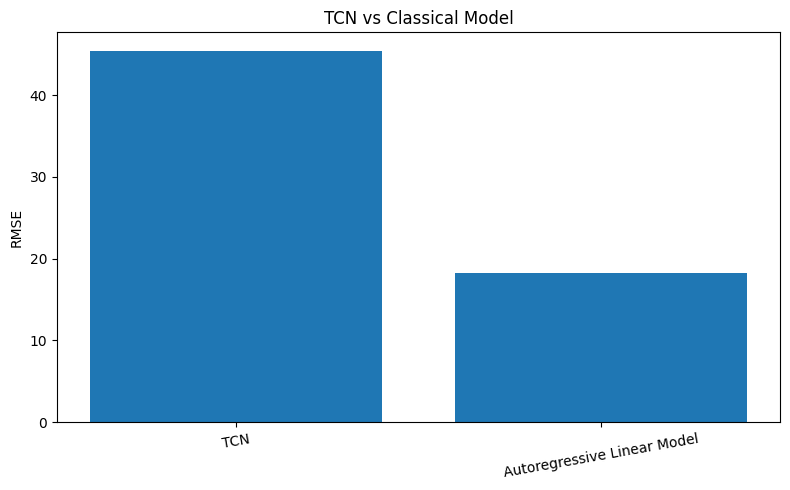

In [40]:
#Step 29 — Plot Model Error Comparison
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "TCN vs Classical Model"
)

plt.xticks(
    rotation=10
)

plt.tight_layout()

plt.show()

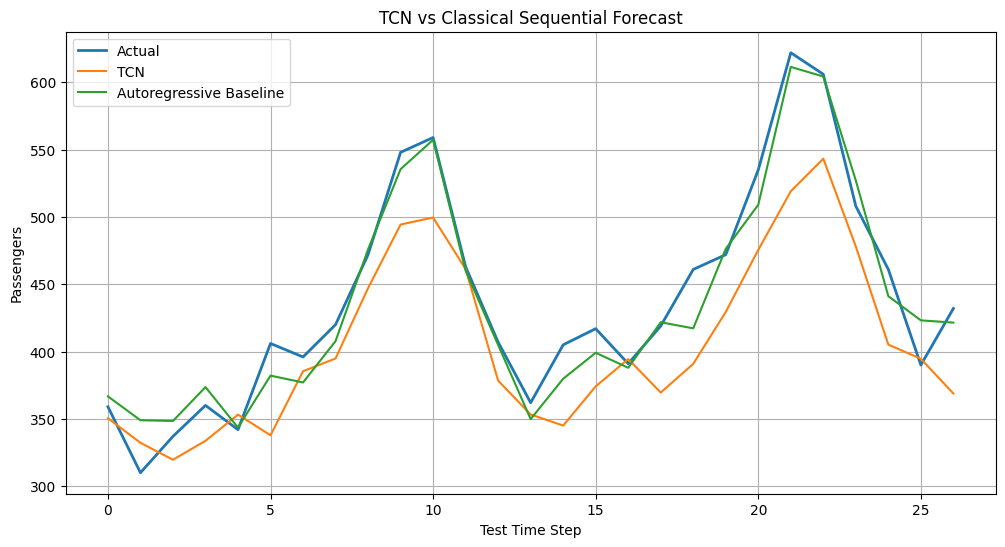

In [41]:
#Step 30 — Compare Predictions Visually
plt.figure(
    figsize=(12, 6)
)

plt.plot(
    actual_original,
    label="Actual",
    linewidth=2
)

plt.plot(
    predictions_original,
    label="TCN"
)

plt.plot(
    baseline_original,
    label="Autoregressive Baseline"
)

plt.xlabel(
    "Test Time Step"
)

plt.ylabel(
    "Passengers"
)

plt.title(
    "TCN vs Classical Sequential Forecast"
)

plt.legend()

plt.grid()

plt.show()

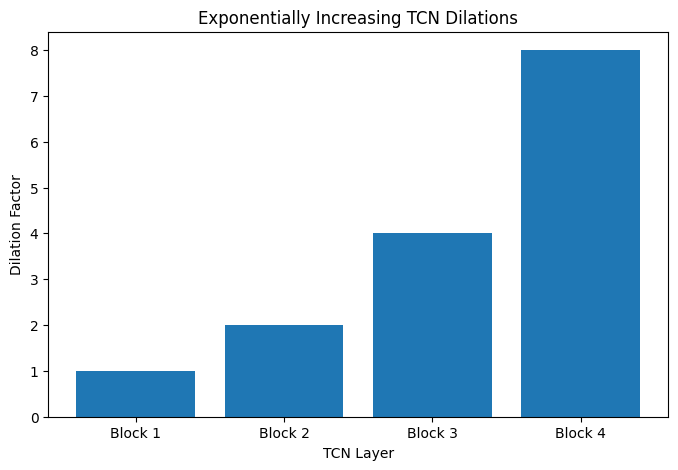

In [42]:
#Step 31 — Visualize Dilation Structure
dilation_values = [
    1,
    2,
    4,
    8
]

layer_names = [
    "Block 1",
    "Block 2",
    "Block 3",
    "Block 4"
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    layer_names,
    dilation_values
)

plt.xlabel(
    "TCN Layer"
)

plt.ylabel(
    "Dilation Factor"
)

plt.title(
    "Exponentially Increasing TCN Dilations"
)

plt.show()